C:\Users\wbwha\AppData\Local\Temp\ipykernel_3068\3707153040.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


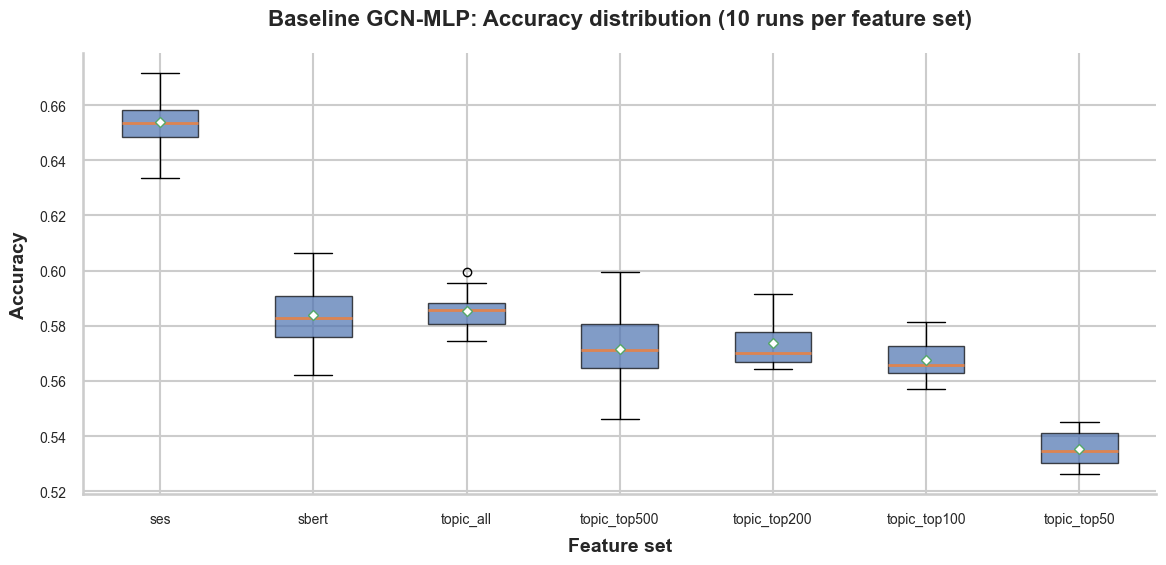

C:\Users\wbwha\AppData\Local\Temp\ipykernel_3068\3707153040.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


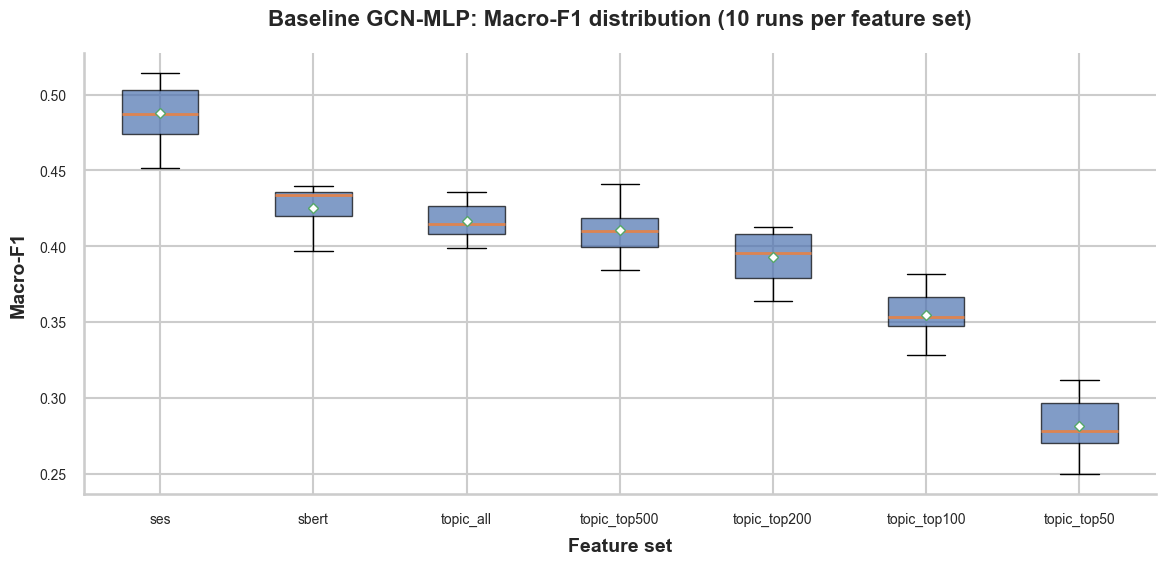

C:\Users\wbwha\AppData\Local\Temp\ipykernel_3068\3707153040.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


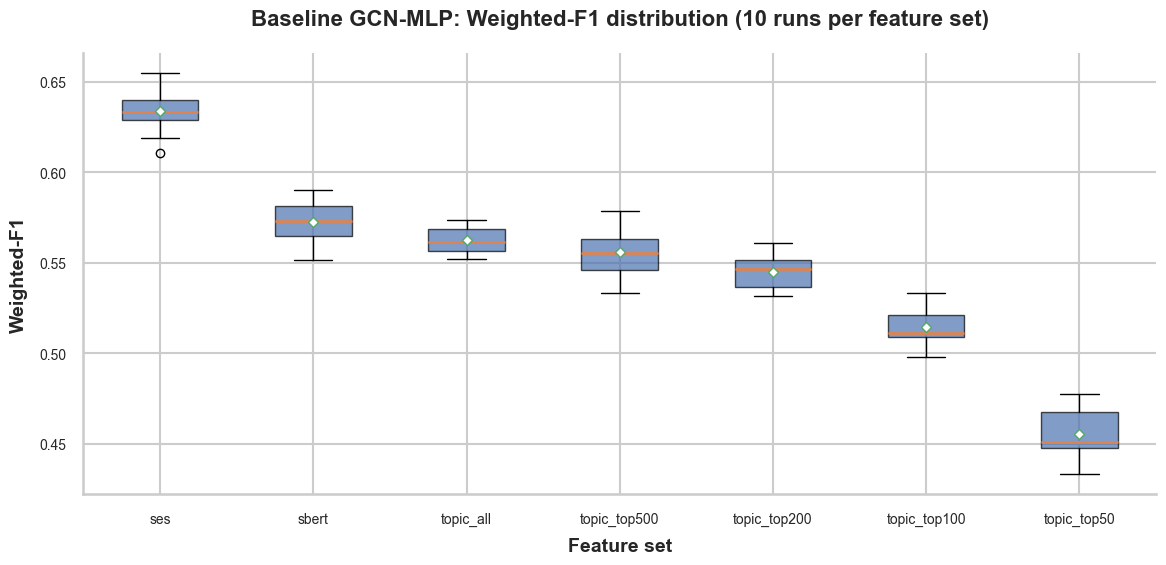

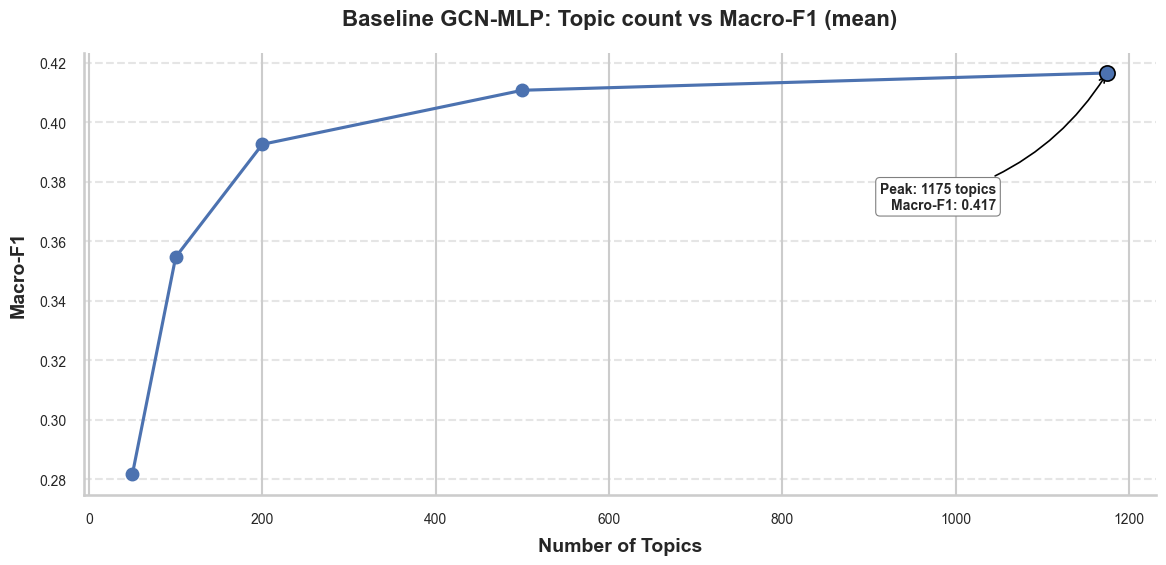

In [5]:
import os, textwrap, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, readable theme using seaborn
sns.set_theme(context="talk", style="whitegrid")

# Apply consistent matplotlib style tweaks
plt.rcParams.update({
    "axes.spines.top": False,      # Remove top border
    "axes.spines.right": False,    # Remove right border
    "axes.titleweight": "bold",    # Bold titles
    "axes.titlepad": 20,           # Padding for titles
    "axes.labelpad": 8,            # Padding for axis labels
    "figure.autolayout": False,    # We'll control layout manually
})

SAVE_DIR = "../Output/Performance"
os.makedirs(SAVE_DIR, exist_ok=True)

def savefig(path):
    plt.savefig(path, dpi=200, bbox_inches="tight")

def wrap_labels(labels, width=16):
    return ["\n".join(textwrap.wrap(str(lbl), width=width, break_long_words=False)) for lbl in labels]

# ===== Load summary =====
mlp_summary_path = os.path.join(SAVE_DIR, "gcn_mlp_dataset_comparison.csv")
mlp_seed_path    = os.path.join(SAVE_DIR, "gcn_mlp_dataset_per_seed_long.csv")  # 只有你另存了per-seed时才会存在

results_df = pd.read_csv(mlp_summary_path)

# Rename to align with your XGB plotting code style
results_df = results_df.rename(columns={
    "dataset": "feature_set",
    "macro_f1_mean": "f1_macro_mean",
    "macro_f1_std":  "f1_macro_std",
    "weighted_f1_mean": "f1_weighted_mean",
    "weighted_f1_std":  "f1_weighted_std",
    "accuracy_mean": "acc_mean",
    "accuracy_std":  "acc_std"
})

# Sort by Macro-F1 mean
if "f1_macro_mean" in results_df.columns and "feature_set" in results_df.columns:
    results_df = results_df.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)

order = results_df["feature_set"].tolist()

# Boxplots for all three metrics (only if per-seed exists) =====
if os.path.exists(mlp_seed_path):
    long_df = pd.read_csv(mlp_seed_path)
    # Expect columns: feature_set(or dataset), seed, macro_f1, weighted_f1, accuracy
    if "dataset" in long_df.columns and "feature_set" not in long_df.columns:
        long_df = long_df.rename(columns={"dataset": "feature_set"})
    # Melt to metric-long
    per_seed_rows = []
    for _, r in long_df.iterrows():
        per_seed_rows.append({"feature_set": r["feature_set"], "metric": "Accuracy",   "score": r["accuracy"]})
        per_seed_rows.append({"feature_set": r["feature_set"], "metric": "Macro-F1",   "score": r["macro_f1"]})
        per_seed_rows.append({"feature_set": r["feature_set"], "metric": "Weighted-F1","score": r["weighted_f1"]})
    long_df2 = pd.DataFrame(per_seed_rows)
    long_df2["feature_set"] = pd.Categorical(long_df2["feature_set"], categories=order, ordered=True)

    for metric in ["Accuracy", "Macro-F1", "Weighted-F1"]:
        subset = long_df2[long_df2["metric"] == metric].copy()
        groups = [g["score"].values for _, g in subset.groupby("feature_set", observed=True)]
        labels = [k for k, _ in subset.groupby("feature_set", observed=True)]

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_title(f"Baseline GCN-MLP: {metric} distribution ({len(groups[0]) if groups else 0} runs per feature set)", fontsize=16, fontweight='bold', pad=20)
        bp = ax.boxplot(
            groups,
            labels=wrap_labels(labels, width=18),
            showmeans=True,
            meanprops=dict(marker='D', markersize=5, markerfacecolor='white'),
            patch_artist=True
        )
        for patch in bp['boxes']:
            patch.set_alpha(0.7)
        for median in bp['medians']:
            median.set_linewidth(2)
        ax.set_xlabel("Feature set", fontsize=14, fontweight='bold')
        ax.set_ylabel(metric, fontsize=14, fontweight='bold')
        ax.tick_params(axis='both', labelsize=10)
        plt.tight_layout()
        savefig(os.path.join(SAVE_DIR, f"gcn_mlp_{metric.lower().replace('-', '_')}_box.png"))
        plt.show()
else:
    print("No per-seed CSV for GCN-MLP; skipping boxplots.")

# Topic count vs Macro-F1 curve =====
topic_sizes = [("topic_top50", 50), ("topic_top100", 100), ("topic_top200", 200), ("topic_top500", 500), ("topic_all", 1175)]
curve_points = []
for name, k in topic_sizes:
    row = results_df[results_df["feature_set"] == name]
    if not row.empty:
        curve_points.append((k, float(row["f1_macro_mean"].iloc[0])))

if curve_points:
    curve_points = sorted(curve_points, key=lambda x: x[0])
    ks, scores = zip(*curve_points)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(ks, scores, marker="o")
    ax.set_title("Baseline GCN-MLP: Topic count vs Macro-F1 (mean)", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Number of Topics", fontsize=14, fontweight='bold')
    ax.set_ylabel("Macro-F1", fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)

    best_i = int(np.argmax(scores))
    peak_x = ks[best_i]; peak_y = scores[best_i]
    ax.scatter(peak_x, peak_y, s=120, edgecolor="black", linewidth=1.2, zorder=5)
    offset_x = 10 if peak_x < max(ks) else -80
    offset_y = -100
    ax.annotate(
        f"Peak: {peak_x} topics\nMacro-F1: {peak_y:.3f}",
        xy=(peak_x, peak_y),
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        ha="left" if offset_x > 0 else "right",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.8),
        arrowprops=dict(arrowstyle="->", lw=1.2, color="black", connectionstyle="arc3,rad=0.2")
    )
    plt.tight_layout()
    savefig(os.path.join(SAVE_DIR, "gcn_mlp_topiccount_vs_macro_f1.png"))
    plt.show()

C:\Users\wbwha\AppData\Local\Temp\ipykernel_3068\3864121339.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


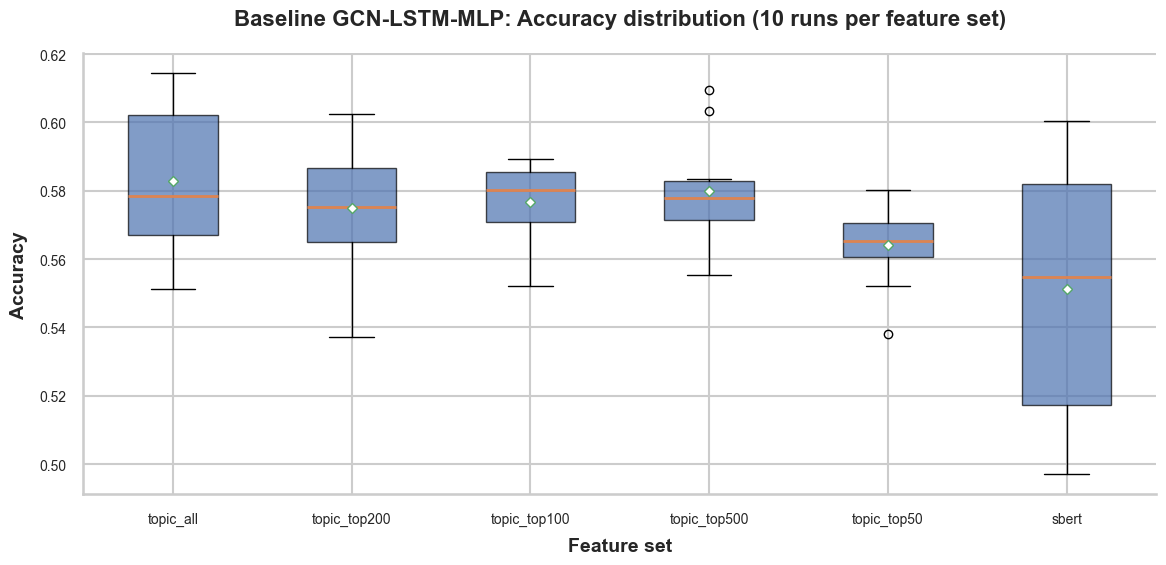

C:\Users\wbwha\AppData\Local\Temp\ipykernel_3068\3864121339.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


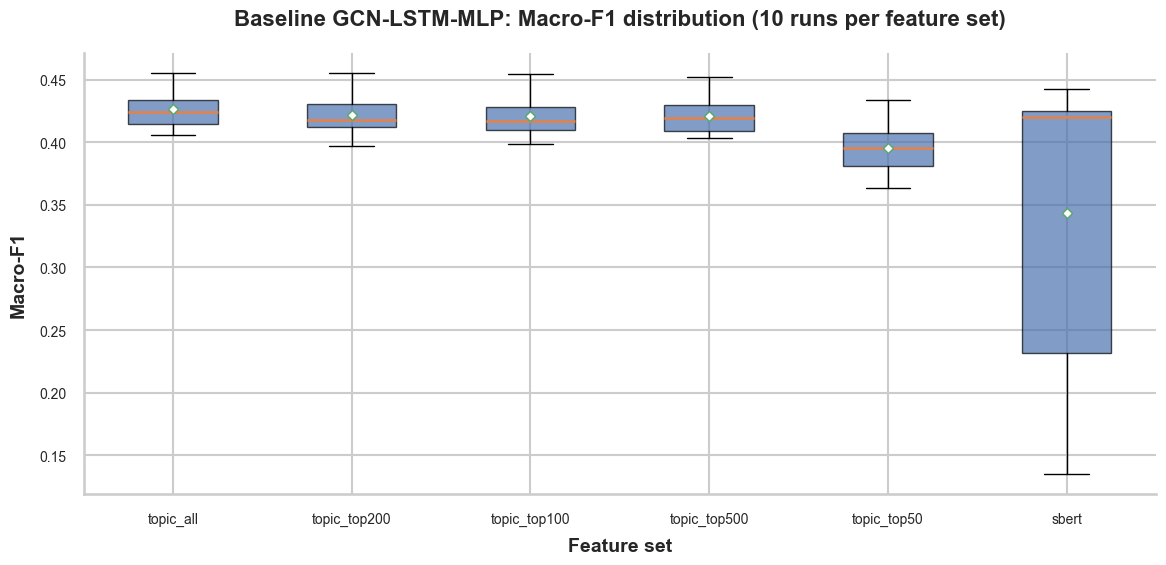

C:\Users\wbwha\AppData\Local\Temp\ipykernel_3068\3864121339.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


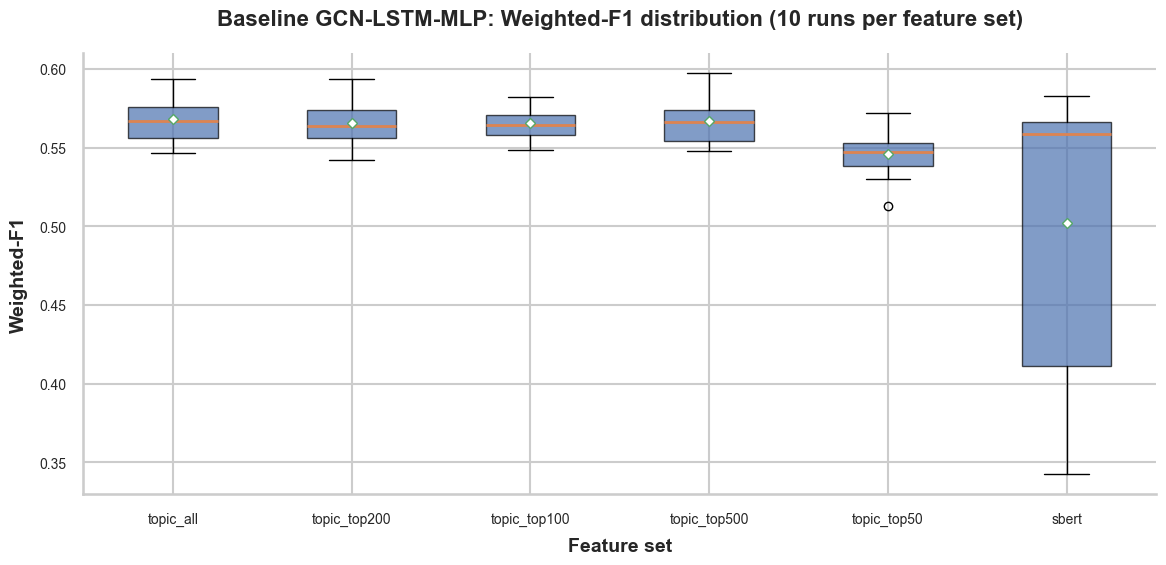

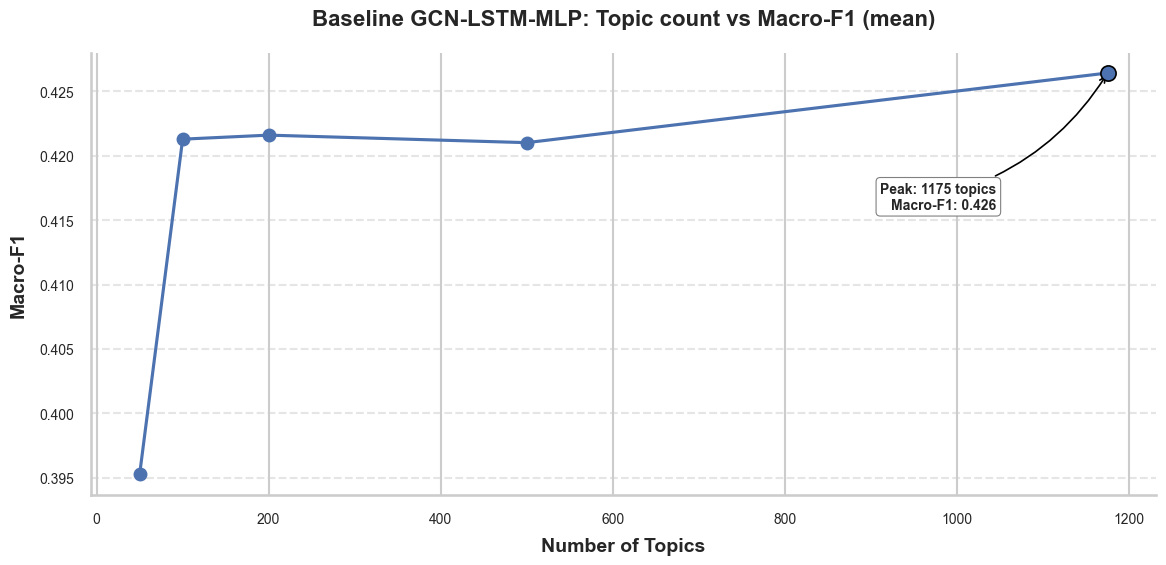

In [6]:
import os, textwrap, numpy as np, pandas as pd
import matplotlib.pyplot as plt

SAVE_DIR = "../Output/Performance"
os.makedirs(SAVE_DIR, exist_ok=True)

def savefig(path):
    plt.savefig(path, dpi=200, bbox_inches="tight")

def wrap_labels(labels, width=16):
    return ["\n".join(textwrap.wrap(str(lbl), width=width, break_long_words=False)) for lbl in labels]

# ===== Load summary & per-seed =====
lstm_summary_path = os.path.join(SAVE_DIR, "gcn_lstm_dataset_comparison.csv")
lstm_seed_path    = os.path.join(SAVE_DIR, "gcn_lstm_dataset_per_seed_long.csv")

results_df = pd.read_csv(lstm_summary_path)
results_df = results_df.rename(columns={
    "dataset": "feature_set",
    "macro_f1_mean": "f1_macro_mean",
    "macro_f1_std":  "f1_macro_std",
    "weighted_f1_mean": "f1_weighted_mean",
    "weighted_f1_std":  "f1_weighted_std",
    "accuracy_mean": "acc_mean",
    "accuracy_std":  "acc_std"
})

# Sort by Macro-F1 mean
if "f1_macro_mean" in results_df.columns and "feature_set" in results_df.columns:
    results_df = results_df.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)
order = results_df["feature_set"].tolist()

# Boxplots for all three metrics (per-seed long) =====
seed_df = pd.read_csv(lstm_seed_path)
if "dataset" in seed_df.columns and "feature_set" not in seed_df.columns:
    seed_df = seed_df.rename(columns={"dataset": "feature_set"})

per_seed_rows = []
for _, r in seed_df.iterrows():
    per_seed_rows.append({"feature_set": r["feature_set"], "metric": "Accuracy",   "score": r["accuracy"]})
    per_seed_rows.append({"feature_set": r["feature_set"], "metric": "Macro-F1",   "score": r["macro_f1"]})
    per_seed_rows.append({"feature_set": r["feature_set"], "metric": "Weighted-F1","score": r["weighted_f1"]})
long_df = pd.DataFrame(per_seed_rows)
long_df["feature_set"] = pd.Categorical(long_df["feature_set"], categories=order, ordered=True)

for metric in ["Accuracy", "Macro-F1", "Weighted-F1"]:
    subset = long_df[long_df["metric"] == metric].copy()
    groups = [g["score"].values for _, g in subset.groupby("feature_set", observed=True)]
    labels = [k for k, _ in subset.groupby("feature_set", observed=True)]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(f"Baseline GCN-LSTM-MLP: {metric} distribution ({len(groups[0]) if groups else 0} runs per feature set)", fontsize=16, fontweight='bold', pad=20)
    bp = ax.boxplot(
        groups,
        labels=wrap_labels(labels, width=18),
        showmeans=True,
        meanprops=dict(marker='D', markersize=5, markerfacecolor='white'),
        patch_artist=True
    )
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set_linewidth(2)

    ax.set_xlabel("Feature set", fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    savefig(os.path.join(SAVE_DIR, f"gcn_lstm_{metric.lower().replace('-', '_')}_box.png"))
    plt.show()

# Topic count vs Macro-F1 curve =====
topic_sizes = [("topic_top50", 50), ("topic_top100", 100), ("topic_top200", 200), ("topic_top500", 500), ("topic_all", 1175)]
curve_points = []
for name, k in topic_sizes:
    row = results_df[results_df["feature_set"] == name]
    if not row.empty:
        curve_points.append((k, float(row["f1_macro_mean"].iloc[0])))

if curve_points:
    curve_points = sorted(curve_points, key=lambda x: x[0])
    ks, scores = zip(*curve_points)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(ks, scores, marker="o")
    ax.set_title("Baseline GCN-LSTM-MLP: Topic count vs Macro-F1 (mean)", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Number of Topics", fontsize=14, fontweight='bold')
    ax.set_ylabel("Macro-F1", fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)

    best_i = int(np.argmax(scores))
    peak_x = ks[best_i]; peak_y = scores[best_i]
    ax.scatter(peak_x, peak_y, s=120, edgecolor="black", linewidth=1.2, zorder=5)
    offset_x = 10 if peak_x < max(ks) else -80
    offset_y = -100
    ax.annotate(
        f"Peak: {peak_x} topics\nMacro-F1: {peak_y:.3f}",
        xy=(peak_x, peak_y),
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        ha="left" if offset_x > 0 else "right",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.8),
        arrowprops=dict(arrowstyle="->", lw=1.2, color="black", connectionstyle="arc3,rad=0.2")
    )
    plt.tight_layout()
    savefig(os.path.join(SAVE_DIR, "gcn_lstm_topiccount_vs_macro_f1.png"))
    plt.show()